In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Configuración plots
plt.style.use("seaborn-v0_8")

In [ ]:
# Base paths
from pathlib import Path
BASE_PATH = Path(".")

DATA_PATH = BASE_PATH / "data" / "processed"
TABLES_PATH = BASE_PATH / "tables" / "chapter6"
FIGURES_PATH = BASE_PATH / "figures" / "chapter6"

PROJECT_ROOT = Path("/home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio")

DATA_PATH = PROJECT_ROOT / "data" / "processed"

# Crear carpetas si no existen
TABLES_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

In [5]:
# Backtest ML (Notebook 06)
ml_bt = pd.read_csv(DATA_PATH / "backtest_ml_results.csv")

# Backtest régimen real (Notebook 04)
regime_bt = pd.read_csv(DATA_PATH / "backtest_oos_results.csv")

In [6]:
print("ML backtest columns:")
print(ml_bt.columns.tolist())

print("\nRegime backtest columns:")
print(regime_bt.columns.tolist())

print("\nML shape:", ml_bt.shape)
print("Regime shape:", regime_bt.shape)

display(ml_bt.head())
display(regime_bt.head())

ML backtest columns:
['date', 'sample_split_main', 'ret_1d', 'regime', 'regime_t_plus_1', 'regime_pred', 'proba_0', 'proba_1', 'proba_2', 'target_exposure_ml_hard', 'target_exposure_ml_proba', 'strategy_exposure_ml_hard', 'strategy_exposure_ml_proba', 'benchmark_return', 'ml_hard_return', 'ml_proba_return', 'benchmark_cum', 'ml_hard_cum', 'ml_proba_cum', 'benchmark_drawdown', 'ml_hard_drawdown', 'ml_proba_drawdown']

Regime backtest columns:
['date', 'sample_split_main', 'sample_split_robust', 'ret_1d', 'ewma_vol', 'cvar_95_60d', 'p_regime_0', 'p_regime_1', 'p_regime_2', 'regime', 'target_exposure', 'strategy_exposure', 'benchmark_return', 'strategy_return', 'benchmark_cum', 'strategy_cum', 'target_exposure_alt', 'strategy_exposure_alt', 'strategy_return_alt', 'strategy_cum_alt']

ML shape: (1355, 22)
Regime shape: (1356, 20)


,date,sample_split_main,ret_1d,regime,regime_t_plus_1,regime_pred,proba_0,proba_1,proba_2,target_exposure_ml_hard,...,strategy_exposure_ml_proba,benchmark_return,ml_hard_return,ml_proba_return,benchmark_cum,ml_hard_cum,ml_proba_cum,benchmark_drawdown,ml_hard_drawdown,ml_proba_drawdown
0,2021-01-05,test,-0.000951,0,2,2,0.074493,0.000889,0.924617,0.75,...,0.757208,-0.000951,-0.000713,-0.000720,0.999049,0.999287,0.999280,0.000000,0.000000,0.000000
1,2021-01-06,test,0.031483,2,2,2,0.002597,0.002011,0.995391,0.75,...,0.768179,0.031483,0.023612,0.024185,1.031003,1.023163,1.023742,0.000000,0.000000,0.000000
2,2021-01-07,test,0.004242,2,2,2,0.008457,0.001637,0.989905,0.75,...,0.749644,0.004242,0.003182,0.003180,1.035386,1.026424,1.027003,0.000000,0.000000,0.000000
3,2021-01-08,test,0.002608,2,2,2,0.009446,0.001635,0.988919,0.75,...,0.751296,0.002608,0.001956,0.001960,1.038090,1.028434,1.029017,0.000000,0.000000,0.000000
4,2021-01-11,test,-0.005989,2,2,2,0.017201,0.001090,0.981710,0.75,...,0.751544,-0.005989,-0.004491,-0.004501,1.031892,1.023825,1.024396,-0.005971,-0.004481,-0.004491


,date,sample_split_main,sample_split_robust,ret_1d,ewma_vol,cvar_95_60d,p_regime_0,p_regime_1,p_regime_2,regime,target_exposure,strategy_exposure,benchmark_return,strategy_return,benchmark_cum,strategy_cum,target_exposure_alt,strategy_exposure_alt,strategy_return_alt,strategy_cum_alt
0,2021-01-05,test,test,-0.000951,0.012880,-0.026634,0.551363,0.004775,0.443863,0,1.00,0.75,-0.000951,-0.000713,0.999049,0.999287,1.0,0.5,-0.000476,0.999525
1,2021-01-06,test,test,0.031483,0.014677,-0.026634,0.005958,0.068211,0.925831,2,0.75,1.00,0.031483,0.031483,1.031003,1.031248,0.5,1.0,0.031483,1.031493
2,2021-01-07,test,test,0.004242,0.014268,-0.026634,0.038882,0.038853,0.922265,2,0.75,0.75,0.004242,0.003182,1.035386,1.034535,0.5,0.5,0.002121,1.033684
3,2021-01-08,test,test,0.002608,0.013848,-0.026634,0.097578,0.022616,0.879806,2,0.75,0.75,0.002608,0.001956,1.038090,1.036560,0.5,0.5,0.001304,1.035033
4,2021-01-11,test,test,-0.005989,0.013506,-0.026634,0.141543,0.015689,0.842768,2,0.75,0.75,-0.005989,-0.004491,1.031892,1.031915,0.5,0.5,-0.002994,1.031938


In [7]:
# Selección de columnas necesarias del backtest ML
ml_bt_clean = ml_bt[
    [
        "date",
        "ret_1d",
        "benchmark_return",
        "ml_hard_return",
        "ml_proba_return",
    ]
].copy()

ml_bt_clean = ml_bt_clean.rename(
    columns={
        "benchmark_return": "buy_hold_return",
        "ml_proba_return": "ml_probability_weighted_return",
    }
)

# Selección de columnas necesarias del backtest regime-based
regime_bt_clean = regime_bt[
    [
        "date",
        "strategy_return",
    ]
].copy()

regime_bt_clean = regime_bt_clean.rename(
    columns={
        "strategy_return": "regime_based_return",
    }
)

# Conversión de fechas
ml_bt_clean["date"] = pd.to_datetime(ml_bt_clean["date"])
regime_bt_clean["date"] = pd.to_datetime(regime_bt_clean["date"])

# Merge por fechas comunes
df_bt = ml_bt_clean.merge(
    regime_bt_clean,
    on="date",
    how="inner",
)

# Ordenar por fecha
df_bt = df_bt.sort_values("date").reset_index(drop=True)

print("Shape ML clean:", ml_bt_clean.shape)
print("Shape regime clean:", regime_bt_clean.shape)
print("Shape merged:", df_bt.shape)
print("Date range:", df_bt["date"].min(), "to", df_bt["date"].max())

display(df_bt.head())

Shape ML clean: (1355, 5)
Shape regime clean: (1356, 2)
Shape merged: (1355, 6)
Date range: 2021-01-05 00:00:00 to 2026-04-22 00:00:00


,date,ret_1d,buy_hold_return,ml_hard_return,ml_probability_weighted_return,regime_based_return
0,2021-01-05,-0.000951,-0.000951,-0.000713,-0.000720,-0.000713
1,2021-01-06,0.031483,0.031483,0.023612,0.024185,0.031483
2,2021-01-07,0.004242,0.004242,0.003182,0.003180,0.003182
3,2021-01-08,0.002608,0.002608,0.001956,0.001960,0.001956
4,2021-01-11,-0.005989,-0.005989,-0.004491,-0.004501,-0.004491


In [8]:
required_columns = [
    "date",
    "ret_1d",
    "buy_hold_return",
    "regime_based_return",
    "ml_hard_return",
    "ml_probability_weighted_return",
]

missing_columns = [col for col in required_columns if col not in df_bt.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if df_bt["date"].duplicated().any():
    raise ValueError("Duplicated dates found after merge.")

if not df_bt["date"].is_monotonic_increasing:
    raise ValueError("Dates are not sorted.")

nan_summary = df_bt[required_columns].isna().sum()

print("Missing values:")
print(nan_summary)

print("\nValidation completed.")

Missing values:
date                              0
ret_1d                            0
buy_hold_return                   0
regime_based_return               0
ml_hard_return                    0
ml_probability_weighted_return    0
dtype: int64

Validation completed.


In [9]:
# Definición de eventos extremos: 5% peor de días del mercado en OOS
tail_threshold = df_bt["ret_1d"].quantile(0.05)

df_bt["stress_tail_event"] = df_bt["ret_1d"] <= tail_threshold

df_stress = df_bt[df_bt["stress_tail_event"]].copy()
df_stress = df_stress.sort_values("date").reset_index(drop=True)

print("Tail threshold, percentile 5:", round(tail_threshold, 6))
print("Total OOS days:", len(df_bt))
print("Stress tail days:", len(df_stress))
print("Stress tail share:", round(len(df_stress) / len(df_bt), 4))
print("Stress period:", df_stress["date"].min(), "to", df_stress["date"].max())
print("Worst market return:", round(df_stress["ret_1d"].min(), 6))

display(df_stress.head())

Tail threshold, percentile 5: -0.015877
Total OOS days: 1355
Stress tail days: 68
Stress tail share: 0.0502
Stress period: 2021-01-15 00:00:00 to 2026-03-19 00:00:00
Worst market return: -0.060081


,date,ret_1d,buy_hold_return,ml_hard_return,ml_probability_weighted_return,regime_based_return,stress_tail_event
0,2021-01-15,-0.017070,-0.017070,-0.012802,-0.013255,-0.017070,True
1,2021-01-25,-0.017460,-0.017460,-0.013095,-0.014435,-0.013095,True
2,2021-01-29,-0.022308,-0.022308,-0.016731,-0.017913,-0.016731,True
3,2021-03-22,-0.017760,-0.017760,-0.017760,-0.016923,-0.017760,True
4,2021-04-20,-0.029354,-0.029354,-0.029354,-0.029134,-0.029354,True


In [10]:
strategy_columns = {
    "Buy & Hold": "buy_hold_return",
    "Regime-based strategy": "regime_based_return",
    "ML hard classification": "ml_hard_return",
    "ML probability-weighted": "ml_probability_weighted_return",
}

In [11]:
strategy_columns = {
    "Buy & Hold": "buy_hold_return",
    "Regime-based strategy": "regime_based_return",
    "ML hard classification": "ml_hard_return",
    "ML probability-weighted": "ml_probability_weighted_return",
}

results = []

for strategy_name, col in strategy_columns.items():
    
    returns = df_stress[col].dropna()
    
    # Métricas básicas
    total_return = (1 + returns).prod() - 1
    mean_return = returns.mean()
    volatility = returns.std()
    
    # VaR y CVaR en cola (coherente con definición)
    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()
    
    worst_day = returns.min()
    
    # Drawdown dentro de los días extremos (acumulado solo en esos días)
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative / rolling_max) - 1
    max_drawdown = drawdown.min()
    
    results.append({
        "strategy": strategy_name,
        "n_days": len(returns),
        "total_return_tail": total_return,
        "mean_return_tail": mean_return,
        "volatility_tail": volatility,
        "VaR_95_tail": var_95,
        "CVaR_95_tail": cvar_95,
        "worst_day": worst_day,
        "max_drawdown_tail": max_drawdown,
    })

df_results_tail = pd.DataFrame(results)

# Ordenar por CVaR (mejor protección arriba)
df_results_tail = df_results_tail.sort_values("CVaR_95_tail")

display(df_results_tail)

,strategy,n_days,total_return_tail,mean_return_tail,volatility_tail,VaR_95_tail,CVaR_95_tail,worst_day,max_drawdown_tail
0,Buy & Hold,68,-0.805905,-0.023772,0.009729,-0.046009,-0.052559,-0.060081,-0.802534
3,ML probability-weighted,68,-0.745880,-0.019912,0.008010,-0.034462,-0.042930,-0.051160,-0.742466
2,ML hard classification,68,-0.746115,-0.019924,0.008203,-0.035510,-0.042770,-0.050836,-0.742823
1,Regime-based strategy,68,-0.737912,-0.019467,0.008042,-0.034507,-0.041677,-0.050836,-0.733361


In [12]:
df_results_tail.to_csv(
    TABLES_PATH / "stress_test_tail_events.csv",
    index=False
)

In [13]:
# Exportar tabla de resultados
output_table_path = TABLES_PATH / "stress_test_tail_events.csv"

df_results_tail.to_csv(output_table_path, index=False)

print(f"Exported table: {output_table_path}")

Exported table: tables/chapter6/stress_test_tail_events.csv


In [14]:
# Curvas acumuladas solo durante los días extremos
df_stress_cum = df_stress[["date"]].copy()

for strategy_name, col in strategy_columns.items():
    df_stress_cum[strategy_name] = (1 + df_stress[col]).cumprod()

display(df_stress_cum.head())

,date,Buy & Hold,Regime-based strategy,ML hard classification,ML probability-weighted
0,2021-01-15,0.982930,0.982930,0.987198,0.986745
1,2021-01-25,0.965768,0.970059,0.974270,0.972501
2,2021-01-29,0.944224,0.953829,0.957970,0.955081
3,2021-03-22,0.927455,0.936889,0.940957,0.938918
4,2021-04-20,0.900230,0.909387,0.913336,0.911563


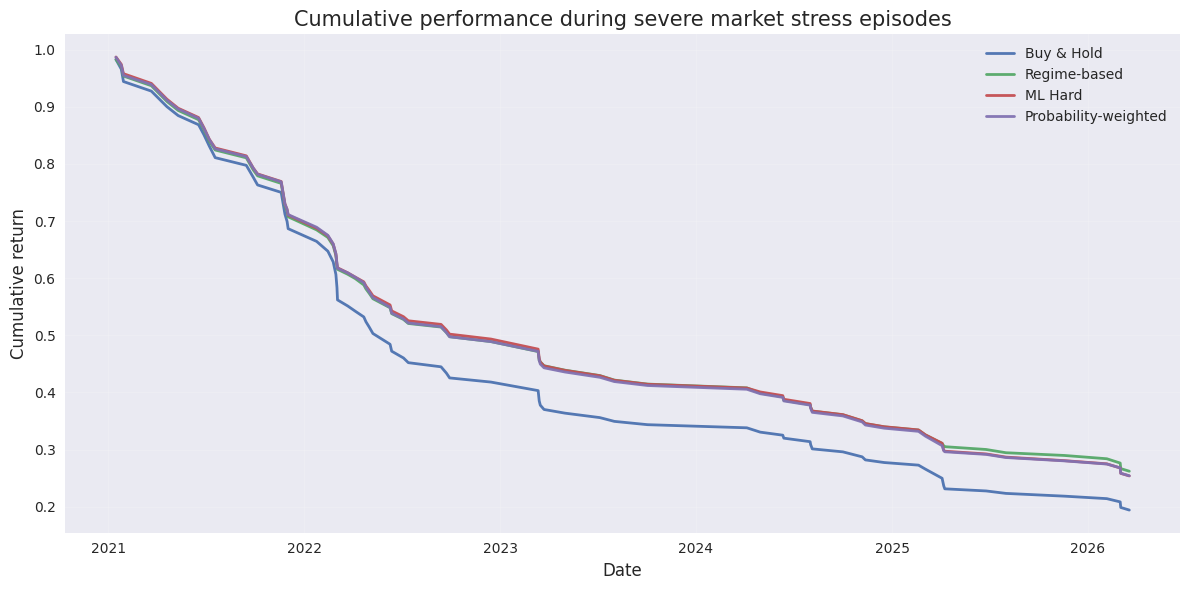

Exported figure: figures/chapter6/stress_tail_cumulative_returns.png


In [15]:
# Gráfico de retornos acumulados durante eventos extremos

plot_labels = {
    "Buy & Hold": "Buy & Hold",
    "Regime-based strategy": "Regime-based",
    "ML hard classification": "ML Hard",
    "ML probability-weighted": "Probability-weighted",
}

plt.figure(figsize=(12, 6))

for strategy_name in strategy_columns.keys():

    plt.plot(
        df_stress_cum["date"],
        df_stress_cum[strategy_name],
        label=plot_labels.get(strategy_name, strategy_name),
        linewidth=2,
        alpha=0.95,
    )

plt.title(
    "Cumulative performance during severe market stress episodes",
    fontsize=15,
)

plt.xlabel("Date", fontsize=12)

plt.ylabel(
    "Cumulative return",
    fontsize=12,
)

plt.legend(frameon=False)

plt.grid(True, alpha=0.15)

plt.tight_layout()

output_figure_path = FIGURES_PATH / "stress_tail_cumulative_returns.png"

plt.savefig(
    output_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Exported figure: {output_figure_path}")

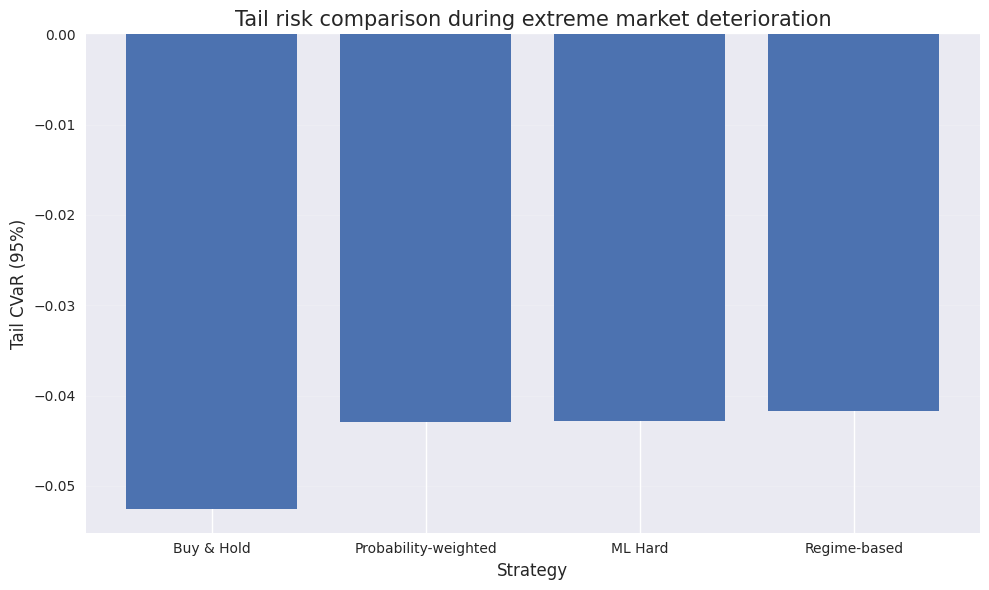

Exported figure: figures/chapter6/stress_tail_bar_comparison.png


In [16]:
# Bar chart: Tail CVaR comparison during stress periods

df_bar = df_results_tail.copy()

df_bar["strategy_clean"] = df_bar["strategy"].replace(
    {
        "Buy & Hold": "Buy & Hold",
        "Regime-based strategy": "Regime-based",
        "ML hard classification": "ML Hard",
        "ML probability-weighted": "Probability-weighted",
    }
)

plt.figure(figsize=(10, 6))

plt.bar(
    df_bar["strategy_clean"],
    df_bar["CVaR_95_tail"],
)

plt.title(
    "Tail risk comparison during extreme market deterioration",
    fontsize=15,
)

plt.xlabel(
    "Strategy",
    fontsize=12,
)

plt.ylabel(
    "Tail CVaR (95%)",
    fontsize=12,
)

plt.grid(
    axis="y",
    alpha=0.15,
)

plt.tight_layout()

output_bar_path = FIGURES_PATH / "stress_tail_bar_comparison.png"

plt.savefig(
    output_bar_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Exported figure: {output_bar_path}")

In [17]:
print("Stress testing tail events completed.")
print(f"Total OOS days: {len(df_bt)}")
print(f"Stress tail days: {len(df_stress)}")
print(f"Tail threshold: {tail_threshold:.6f}")
print(f"Strategies compared: {list(strategy_columns.keys())}")
print(f"Exported table: {output_table_path}")
print(f"Exported figure: {output_figure_path}")
print(f"Exported figure: {output_bar_path}")

Stress testing tail events completed.
Total OOS days: 1355
Stress tail days: 68
Tail threshold: -0.015877
Strategies compared: ['Buy & Hold', 'Regime-based strategy', 'ML hard classification', 'ML probability-weighted']
Exported table: tables/chapter6/stress_test_tail_events.csv
Exported figure: figures/chapter6/stress_tail_cumulative_returns.png
Exported figure: figures/chapter6/stress_tail_bar_comparison.png
